<a href="https://colab.research.google.com/github/Abel-Kurian/Ai-internship/blob/main/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torch torchvision matplotlib

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(100,256),
            nn.ReLU(),
            nn.Linear(256,512),
            nn.ReLU(),
            nn.Linear(512,784),
            nn.Tanh()
        )

    def forward(self,x):
        return self.model(x)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784,512),
            nn.LeakyReLU(0.2),
            nn.Linear(512,256),
            nn.LeakyReLU(0.2),
            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(),lr=0.0002)
optimizer_D = torch.optim.Adam(D.parameters(),lr=0.0002)

epochs = 20

for epoch in range(epochs):

    for imgs,_ in loader:

        real_imgs = imgs.view(-1,784).to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size,1).to(device)
        fake_labels = torch.zeros(batch_size,1).to(device)

        # Train D
        outputs = D(real_imgs)
        d_real_loss = criterion(outputs,real_labels)

        z = torch.randn(batch_size,100).to(device)
        fake_imgs = G(z)

        outputs = D(fake_imgs.detach())
        d_fake_loss = criterion(outputs,fake_labels)

        d_loss = d_real_loss + d_fake_loss

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # Train G
        outputs = D(fake_imgs)

        g_loss = criterion(outputs,real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] D:{d_loss.item():.4f} G:{g_loss.item():.4f}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 308kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.0MB/s]


Epoch [1/20] D:0.0882 G:4.2765
Epoch [2/20] D:0.0143 G:7.6048
Epoch [3/20] D:0.0765 G:7.3554
Epoch [4/20] D:0.2631 G:5.3892
Epoch [5/20] D:0.0783 G:5.4473
Epoch [6/20] D:0.4339 G:5.8844
Epoch [7/20] D:0.2994 G:4.5776
Epoch [8/20] D:0.2474 G:4.9707
Epoch [9/20] D:0.4298 G:2.6707
Epoch [10/20] D:0.2060 G:3.6378
Epoch [11/20] D:0.2126 G:3.7327
Epoch [12/20] D:0.5428 G:4.2833
Epoch [13/20] D:0.3187 G:2.8955
Epoch [14/20] D:0.2801 G:3.9377
Epoch [15/20] D:0.2233 G:3.1264
Epoch [16/20] D:0.3316 G:2.7246
Epoch [17/20] D:0.5192 G:3.6519
Epoch [18/20] D:0.4930 G:3.7542
Epoch [19/20] D:0.6643 G:3.3145
Epoch [20/20] D:0.7056 G:2.6044


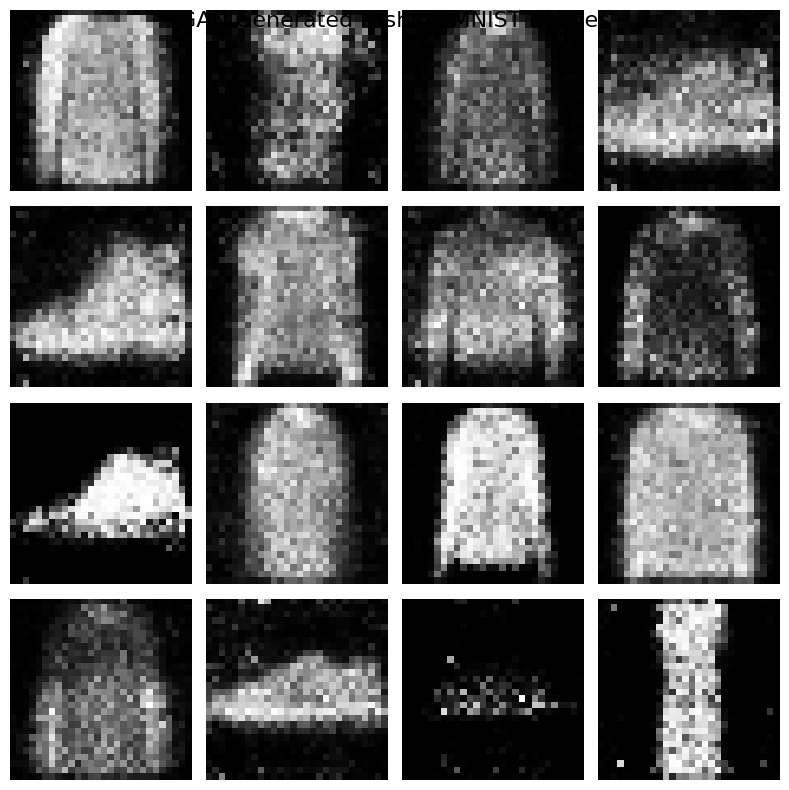

In [4]:
import matplotlib.pyplot as plt
import torch

#generate images
G.eval()

with torch.no_grad():
  z = torch.randn(16,100).to(device)
  generated_img = G(z)

generated_img = generated_img.cpu().view(-1,28,28)

#plot
fig, Axes = plt.subplots(4,4,figsize=(8,8))

for i,ax in enumerate(Axes.flatten()):
  ax.imshow(generated_img[i],cmap='gray')
  ax.axis('off')

plt.tight_layout()
plt.suptitle('GAN Generated Fashion MNIST Images',fontsize=16)
plt.show()


In [7]:
from torchvision.utils import save_image
generated_img = generated_img.unsqueeze(1)

save_image(generated_img,"gan_generated_img.png",nrow = 4,normalize = True)